/tmp/ipykernel_4991/3107610732.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(image_path)
/tmp/ipykernel_4991/3107610732.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imread(mask_path)


Skin Pixels: 33600
Skin Percentage: 26.91%
--------------------------------


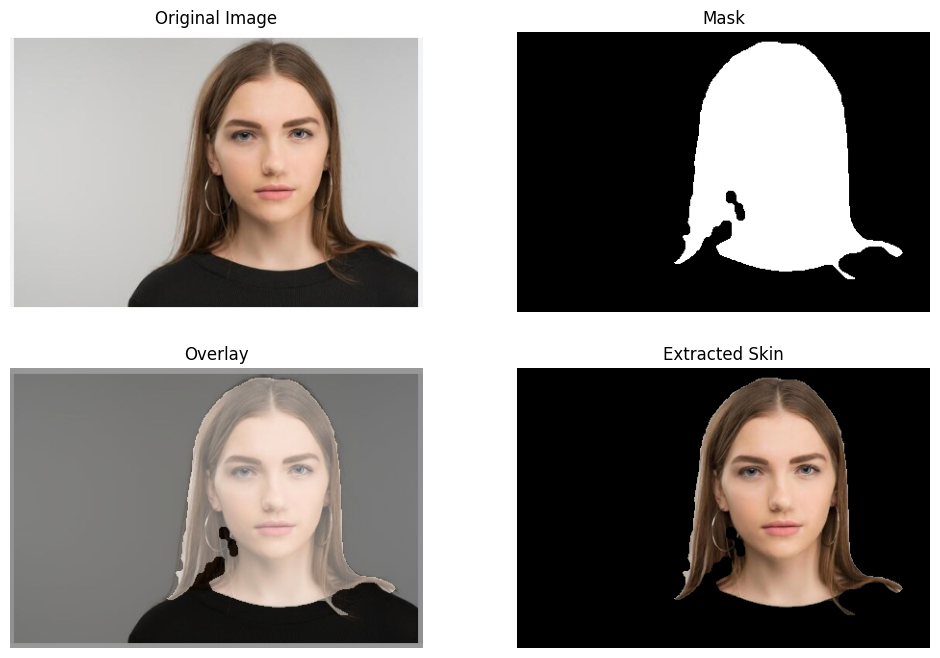

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread

# Image file names (uploaded in Colab)
image_path = "face_image.jpg"
mask_path = "face_mask.png"

# Read images
image = imread(image_path)
mask = imread(mask_path)

# -------------------------------
# Skin Extraction
# -------------------------------

def extract_skin(image, mask):

    mask_rgb = mask[:, :, :3]

    # White pixels = skin
    skin_pixels = np.all(mask_rgb == [255,255,255], axis=-1)

    skin_image = np.zeros_like(image)

    skin_image[skin_pixels] = image[skin_pixels]

    return skin_image, skin_pixels


# -------------------------------
# Display Results
# -------------------------------

def display_results(image, mask, skin_image):

    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(image)
    plt.imshow(mask, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(skin_image)
    plt.title("Extracted Skin")
    plt.axis("off")

    plt.show()


# -------------------------------
# Process Image
# -------------------------------

skin_image, skin_pixels = extract_skin(image, mask)

total_pixels = skin_pixels.size
skin_count = np.sum(skin_pixels)

skin_percentage = (skin_count / total_pixels) * 100

print("Skin Pixels:", skin_count)
print("Skin Percentage: %.2f%%" % skin_percentage)
print("--------------------------------")

display_results(image, mask, skin_image)